In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [40]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Processing train
INFO     | _get_names | Processing normal
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam0 : 535
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam1 : 562
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam0 : 556
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam1 : 555
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam0 : 609
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam1 : 609
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam0 : 639
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam1 : 640
INFO     | _get_names | Image Pair Counts : MOO14_flickering_light cam0 : 714
INFO     | _get_names | Image Pair Counts : MOO14_flickering_light cam1 : 708
INFO     | _get_names | Image Pair Counts : MGO04_hand_shooter_hard cam0 : 741
INFO     | _get_names | Image Pair Counts : MGO04_hand_shooter_hard cam1 : 733
INFO     | _g

In [32]:
dl = dm.train_dataloader()

In [33]:
batch = next(iter(dl))

reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

torch.Size([144, 3, 32, 32]) torch.Size([144, 3, 32, 32])
torch.Size([144, 2]) torch.Size([144, 2])


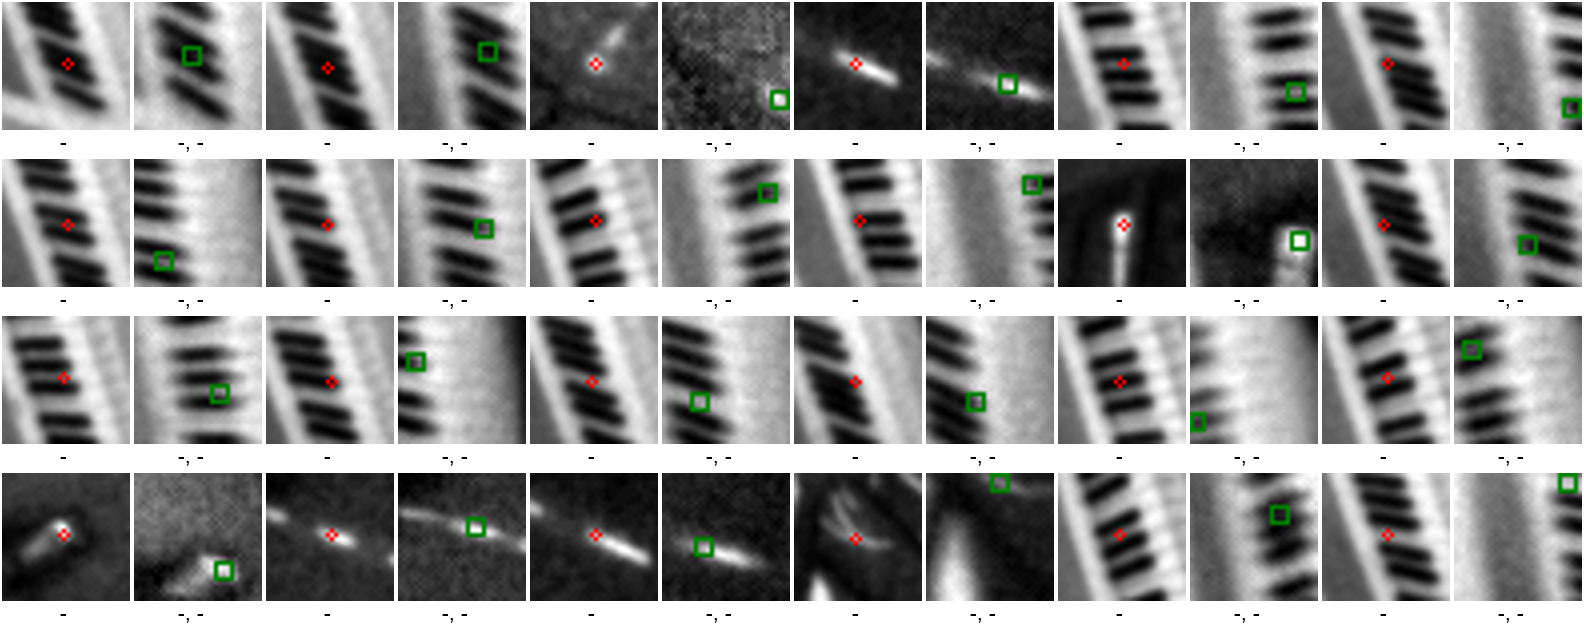

In [34]:
# batch = next(iter(dl))

# reference_patches = batch.reference_patches
# target_patches = batch.target_patches
# print(reference_patches.shape, target_patches.shape) 

# patch_level_reference_coords = batch.patch_level_reference_coords
# patch_level_target_coords = batch.patch_level_target_coords
# print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

count = 24 * 1

# dont forget to comment out PNV

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    # rotations_true=batch.rotations,
    # rotations=batch.rotations,
    limit_count=count, 
    n_columns=6,
    just_gt=True,
)

# Rotation Interpretation
# How to get reference patch using target patch?
# Positive = Anti-clockwise movement
# Negative = Clockwise movement

In [35]:
# print(patch_level_target_coords.shape)

# pred = torch.rand(90, 2) * 2 - 1
# print(pred.shape)

# target = patch_level_target_coords

# # Scale pred from [-1, 1] to [0, 31]
# scaled_pred = (pred.float() + 1) * 15.5 
# print(scaled_pred.shape)

# difference = torch.abs(target - target)
# print(difference.shape)

# # Check which differences exceed N pixels
# exceeds = (difference > 1).any(dim=1)
# print(exceeds.shape)

# # Calculate the percentage
# percentage = (exceeds.sum().item() / scaled_pred.shape[0]) * 100
# print(percentage)

In [36]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

#     rotations = batch.rotations
#     print(rotations.shape)

# Check Model

In [43]:
torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

10,439,619


In [44]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

# target_coords, target_confidence, target_rotation = light(
#     reference_patches, 
#     target_patches, 
#     patch_level_reference_coords
# )

target_coords, target_confidence = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
print(f'target_confidence shape : {target_confidence.shape}')
# print(f'target_rotation shape : {target_rotation.shape}')

Model Inputs
reference_patches shape : torch.Size([144, 3, 32, 32])
target_patches shape : torch.Size([144, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([144, 2])
Model Outputs
target_coords shape : torch.Size([144, 2])
target_confidence shape : torch.Size([144, 1])


In [39]:
from torchinfo import summary

summary(
    light.model, 
    input_data=[
        reference_patches, 
        target_patches, 
        patch_level_reference_coords
    ]
)

Layer (type:depth-idx)                   Output Shape              Param #
MatcherModel                             [144, 2]                  --
├─Sequential: 1-1                        [144, 32, 32, 32]         --
│    └─Conv2d: 2-1                       [144, 32, 32, 32]         2,336
│    └─BatchNorm2d: 2-2                  [144, 32, 32, 32]         64
│    └─ReLU: 2-3                         [144, 32, 32, 32]         --
├─Sequential: 1-2                        [144, 512]                --
│    └─ResNetBlock: 2-4                  [144, 32, 32, 32]         --
│    │    └─Sequential: 3-1              [144, 32, 32, 32]         18,560
│    └─ResNetBlock: 2-5                  [144, 64, 32, 32]         --
│    │    └─Sequential: 3-2              [144, 64, 32, 32]         2,176
│    │    └─Sequential: 3-3              [144, 64, 32, 32]         55,488
│    └─ResNetBlock: 2-6                  [144, 64, 32, 32]         --
│    │    └─Sequential: 3-4              [144, 64, 32, 32]         73,9